**DIAMOND PRICE PREDICTION**

The analysis is based on the diamonds dataset, which contains detailed information on 53,940 diamonds. Each observation represents a single diamond and includes both physical characteristics and quality attributes, along with its market price. The dataset consists of 10 variables:

- price: the price of the diamond expressed in US dollars. This is the response variable and represents the outcome we aim to predict.
- carat: weight of the diamond, measured in carats. One carat is equivalent to 0.2 grams.
- clarity: measure of internal purity. Diamonds often contain imperfections like cracks or mineral deposits. This variable contains 8 ordered levels, from “I1” (the worst) to “IF” (the best).
- color: diamond color. Colorless diamonds are considered better than diamonds with a yellow tint. This variable contains diamonds of 7 different colors, represented by different letters. “D”–“F” diamonds are considered colorless, while “G”–“J” diamonds have a very faint color.
- cut: how a rough diamond is shaped into a finished diamond. Better cuts create more symmetrical and luminous diamonds. This variable has 5 ordered levels: “Fair,” “Good,” “Very Good,” “Premium,” “Ideal”.
- depth: total depth percentage, calculated as the ratio between the diamond's depth and its width.
- table: width of the top of the diamond relative to its widest point.
- x: length of the diamond in millimeters.
- y: width of the diamond in millimeters.
- z: depth of the diamond in millimeters.

The objective of this project is to build and evaluate supervised machine learning models to predict the price of diamonds based on their observable characteristics.
Since the target variable (price) is continuous, the problem is formulated as a regression task. The analysis aims to identify the key factors influencing diamond prices and to develop accurate predictive models.



**Import Libraries**

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import keras as kr
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
import os
os.environ['KERAS_BACKEND']='torch'

**Load Data**

In [9]:
df = pd.read_csv('diamonds.csv')
print('Shape:', df.shape)


Shape: (53940, 10)


**Exploratory Data Analysis (EDA)**

In [10]:
print('\n Summary Statistics:')
print(df.describe().T)

print('\n Missing values:')
print(df.isnull().sum())

print('\n Data types:')
print(df.dtypes)




 Summary Statistics:
         count         mean          std    min     25%      50%      75%  \
carat  53940.0     0.797940     0.474011    0.2    0.40     0.70     1.04   
depth  53940.0    61.749405     1.432621   43.0   61.00    61.80    62.50   
table  53940.0    57.457184     2.234491   43.0   56.00    57.00    59.00   
price  53940.0  3932.799722  3989.439738  326.0  950.00  2401.00  5324.25   
x      53940.0     5.731157     1.121761    0.0    4.71     5.70     6.54   
y      53940.0     5.734526     1.142135    0.0    4.72     5.71     6.54   
z      53940.0     3.538734     0.705699    0.0    2.91     3.53     4.04   

            max  
carat      5.01  
depth     79.00  
table     95.00  
price  18823.00  
x         10.74  
y         58.90  
z         31.80  

 Missing values:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

 Data types:
carat      float64
cut         object
colo

From the descriptive statistics, the dataset includes three categorical variables (\textbf{cut}, \textbf{color}, and \textbf{clarity}) and several numerical variables (\textbf{carat}, \textbf{depth}, \textbf{table}, \textbf{price}, \textbf{x}, \textbf{y}, and \textbf{z}).

The variable \textbf{price} exhibits a wide range (from 326 to 18,823), with a median value of 2,401, indicating a strongly right-skewed distribution and the presence of potential outliers. Similarly, \textbf{carat} ranges from 0.2 to 5.0, with a median of 0.7, suggesting that most diamonds are relatively small, with a limited number of larger observations.

The variables \textbf{x}, \textbf{y}, and \textbf{z}, representing the physical dimensions of the diamond, show substantial variability. However, the presence of zero values indicates unrealistic observations, since a diamond cannot have zero physical dimensions. These values are therefore treated as invalid and removed during the data cleaning process.

The remaining numerical variables, \textbf{depth} and \textbf{table}, show relatively low variability compared to price and carat, indicating more stable measurements across observations.

No missing values are present in the dataset, ensuring completeness of the data. However, the presence of unrealistic observations highlights the importance of thorough data preprocessing beyond simply checking for missing values.

**DATA CLEANING**

In [11]:
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]
print("Dataset after removing zero x, y, or z values:", df.shape)
df1=df.drop_duplicates()
print("Dataset after removing duplicates:", df1.shape)

Dataset after removing zero x, y, or z values: (53920, 10)
Dataset after removing duplicates: (53775, 10)


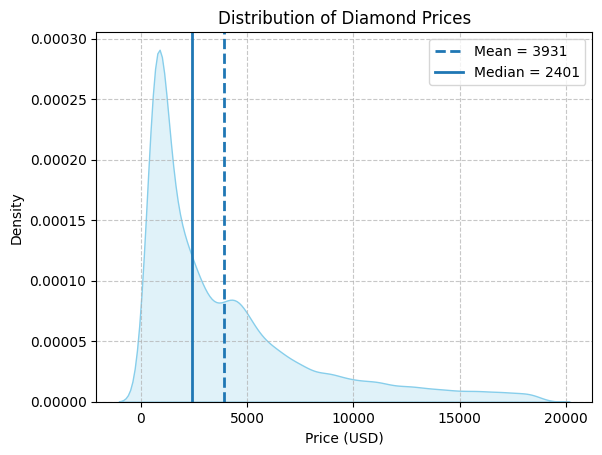

In [12]:
mean_price = df1['price'].mean()
median_price = df1['price'].median()
sns.kdeplot(data=df1, x="price", fill=True, color="skyblue")
plt.axvline(mean_price, linestyle='--', linewidth=2, label=f"Mean = {mean_price:.0f}")
plt.axvline(median_price, linestyle='-', linewidth=2, label=f"Median = {median_price:.0f}")
plt.title("Distribution of Diamond Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The distribution of price is highly right-skewed.
Most diamonds are concentrated in the lower price range, while a small number of observations reach very high values.
This suggests the presence of extreme values and potential non-linear relationships.

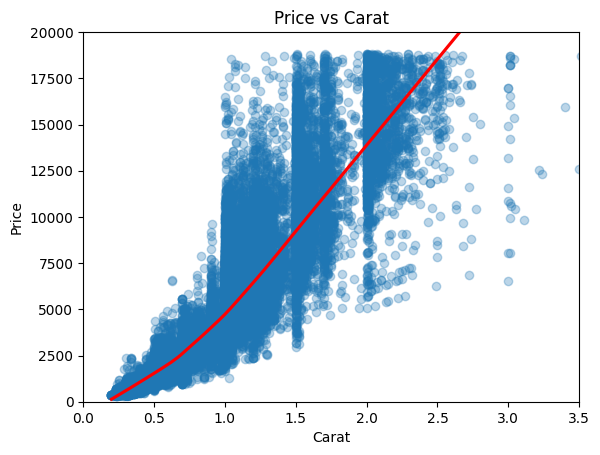

In [13]:
plt.figure()
sns.regplot(data=df1,x="carat",y="price",lowess=True,scatter_kws={"alpha": 0.3},line_kws={"color": "red"})
plt.title("Price vs Carat")
plt.xlabel("Carat")
plt.ylabel("Price")
plt.ylim(0, 20000)
plt.xlim(0,3.5)
plt.show()

There is a strong positive relationship between carat and price.
Larger diamonds tend to have significantly higher prices.
The relationship is clearly non-linear, suggesting the need for flexible models.

/tmp/ipykernel_13111/2760778824.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df1,x="color", y="price",order=['D','E','F','G','H','I','J'] ,palette="viridis")


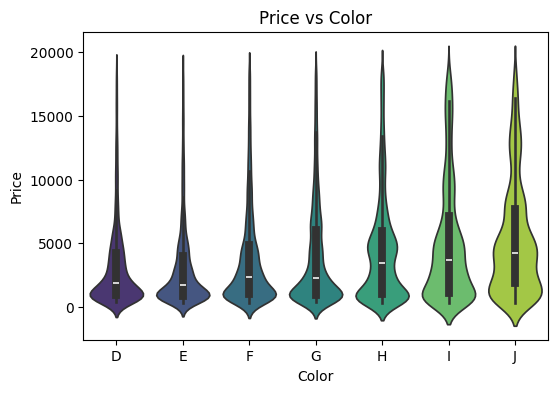

In [14]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df1,x="color", y="price",order=['D','E','F','G','H','I','J'] ,palette="viridis")
plt.title("Price vs Color")
plt.xlabel("Color")
plt.ylabel("Price")
plt.show()

The violin plot shows how price varies across different color grades.
Better color grades (D–F) tend to be associated with lower median prices, although there is considerable variability.
The distributions overlap significantly, indicating that color alone is not sufficient to explain price.

/tmp/ipykernel_13111/2738299794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df1,x="cut", y="price", palette="viridis")


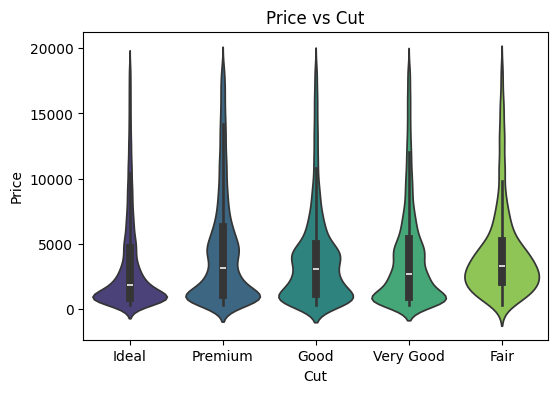

In [15]:
plt.figure(figsize=(6,4))
sns.violinplot(data=df1,x="cut", y="price", palette="viridis")
plt.title("Price vs Cut")
plt.xlabel("Cut")
plt.ylabel("Price")
plt.show()

Price distributions differ across cut categories.
However, the differences are not strictly monotonic, and variability is present in all groups.
This highlights the complexity of the relationship.

/tmp/ipykernel_13111/2463252847.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df1,x="clarity", y="price", palette="viridis", order=['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'])


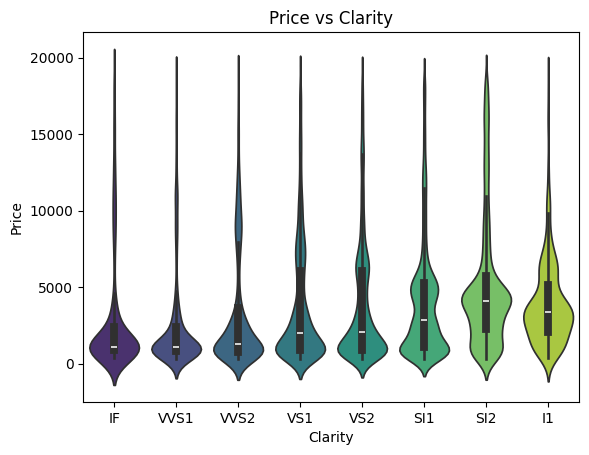

In [16]:
plt.figure()
sns.violinplot(data=df1,x="clarity", y="price", palette="viridis", order=['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1'])
plt.title("Price vs Clarity")
plt.xlabel("Clarity")
plt.ylabel("Price")
plt.show()

Higher clarity levels generally correspond to higher prices.
However, the distributions overlap considerably, indicating that other variables also influence price.

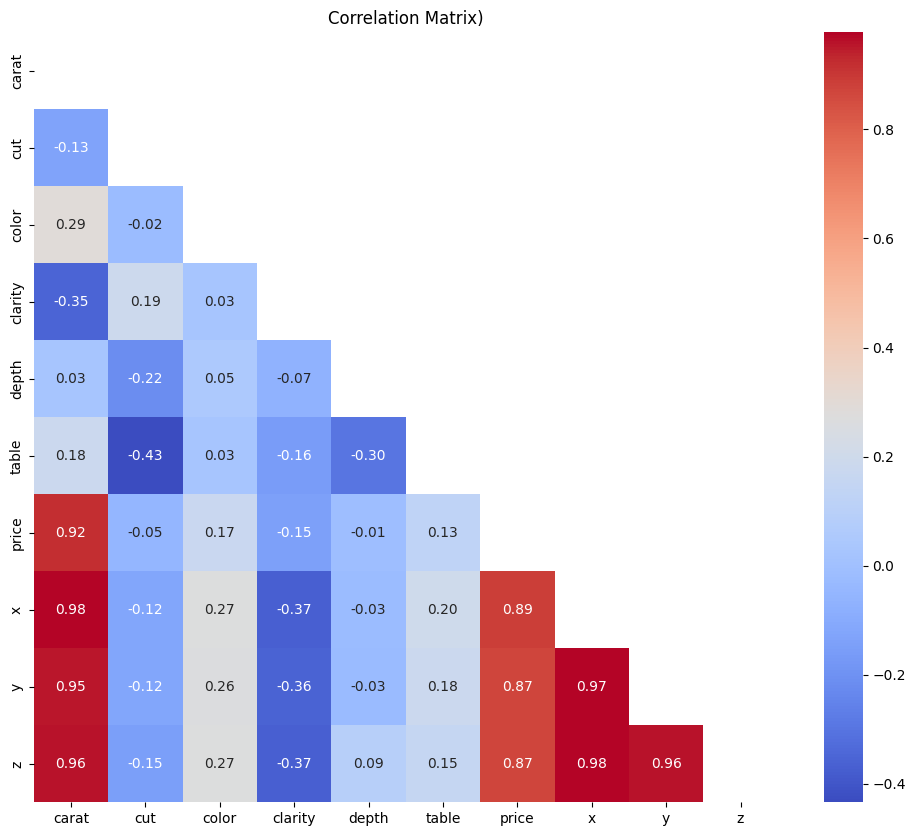

In [17]:
df_for_corr = df1.copy()
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ["D","E","F","G","H","I","J"]
clarity_order = ["I1","SI2","SI1","VS2","VS1","VVS2","VVS1","IF"]
enc_cut = OrdinalEncoder(categories=[cut_order])
df_for_corr['cut'] = enc_cut.fit_transform(df_for_corr[['cut']])
enc_color = OrdinalEncoder(categories=[color_order])
df_for_corr['color'] = enc_color.fit_transform(df_for_corr[['color']])
enc_clarity = OrdinalEncoder(categories=[clarity_order])
df_for_corr['clarity'] = enc_clarity.fit_transform(df_for_corr[['clarity']])
corr_matrix = df_for_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix)')
plt.show()

The correlation matrix highlights strong relationships among numerical variables.
In particular, there is a very strong positive correlation between carat, and the physical dimensions (x, y, z) and price, confirming that size-related features are the main drivers of diamond prices.
Variables x, y, and z are highly correlated with carat, indicating that these variables capture similar information and may introduce multicollinearity.
Other variables, such as depth and table, show weaker correlations with price, suggesting a more limited impact.

**TRAIN/VALIDATION SET**

The dataset is divided into training and validation sets.
This allows evaluating model performance on unseen data and prevents overfitting.

In [18]:
X=df1.drop("price",axis=1)
y = df1["price"]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (43020, 9)
Validation shape: (10755, 9)


**FEATURE ENGINEERING**

Categorical variables are encoded using ordinal encoding to preserve their natural order and label encoding for color.
Numerical variables are standardized using scaling techniques.
These steps are particularly important for neural networks, which require numerical and properly scaled inputs.

In [19]:
enc= OrdinalEncoder()
X_train["clarity"] = enc.fit_transform(X_train[["clarity"]])
X_val["clarity"] = enc.transform(X_val[["clarity"]])
X_train["cut"] = enc.fit_transform(X_train[["cut"]])
X_val["cut"] = enc.transform(X_val[["cut"]])

labenc=LabelEncoder()
X_train["color"] = labenc.fit_transform(X_train["color"])
X_val["color"] = labenc.transform(X_val["color"])

scaler= StandardScaler()
X_train["carat"] = scaler.fit_transform(X_train[["carat"]])
X_val["carat"] = scaler.transform(X_val[["carat"]])
X_train["depth"] = scaler.fit_transform(X_train[["depth"]])
X_val["depth"] = scaler.transform(X_val[["depth"]])
X_train["table"] = scaler.fit_transform(X_train[["table"]])
X_val["table"] = scaler.transform(X_val[["table"]])
X_train["x"] = scaler.fit_transform(X_train[["x"]])
X_val["x"] = scaler.transform(X_val[["x"]])
X_train["y"] = scaler.fit_transform(X_train[["y"]])
X_val["y"] = scaler.transform(X_val[["y"]])
X_train["z"] = scaler.fit_transform(X_train[["z"]])
X_val["z"] = scaler.transform(X_val[["z"]])

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (43020, 9)
Validation shape: (10755, 9)


**XGBOOSTING**

XGBoost is an ensemble learning algorithm based on Gradient Boosting.
It builds multiple decision trees sequentially, where each tree corrects the errors of the previous ones.
The model is optimized by minimizing a loss function with regularization, which helps prevent overfitting.
XGBoost is particularly effective for structured data and can capture complex non-linear relationships.
Key advantages include high predictive accuracy, efficiency, and scalability.
In this project, XGBoost is used to predict diamond prices using both numerical and categorical features.


In [20]:
xgb = XGBRegressor(random_state=42)
param_grid = {"n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "reg_alpha": [0.05, 0.1]}
grid = GridSearchCV(estimator=xgb,param_grid=param_grid,
    cv=10,scoring="neg_mean_squared_error",n_jobs=-1)
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_
print("Best Parameters:", grid.best_params_)
y_pred_xgb = best_xgb.predict(X_val)
mse_xgb = mean_squared_error(y_val, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_val, y_pred_xgb)

print("\nXGBoost Performance:")
print("MSE:", mse_xgb)
print("RMSE:", rmse_xgb)
print("R2:", r2_xgb)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'reg_alpha': 0.05, 'subsample': 1.0}

XGBoost Performance:
MSE: 270427.03125
RMSE: 520.0259909369915
R2: 0.982887864112854


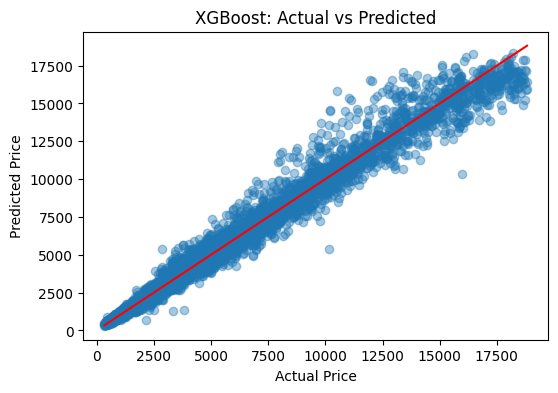

In [21]:

plt.figure(figsize=(6,4))
plt.scatter(y_val, y_pred_xgb, alpha=0.4)
plt.plot([y_val.min(), y_val.max()],[y_val.min(), y_val.max()],color='red')
plt.title("XGBoost: Actual vs Predicted")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

The scatter plot compares actual and predicted diamond prices using the XGBoost model.
Most points lie close to the diagonal line, indicating high predictive accuracy.
The model performs particularly well for lower and medium price ranges.
A slight dispersion is visible for higher prices, suggesting larger prediction errors for expensive diamonds, but overall performance remains very strong.

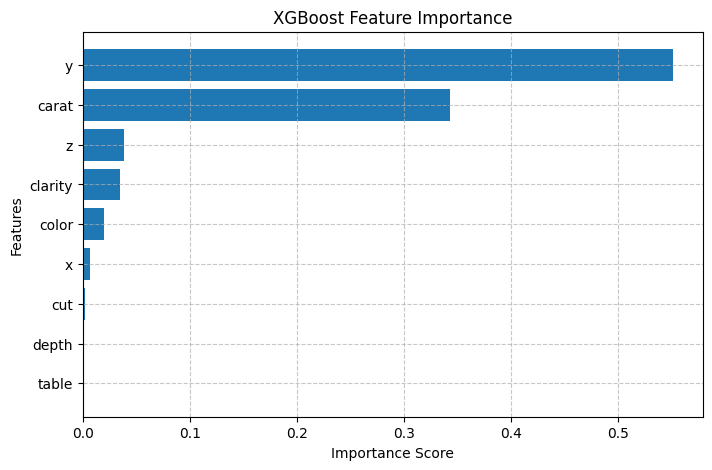

In [29]:

importances = best_xgb.feature_importances_
feature_names = X_train.columns
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)


plt.figure(figsize=(8,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The feature importance plot shows that the variable y is the most influential predictor of diamond price, followed by carat.
This highlights that both the physical dimensions and the weight of the diamond are the primary drivers of price.
The variables z, clarity, and color have a moderate but significantly lower impact, while x contributes only marginally.
Finally, cut, depth, and table have almost no influence on the model, suggesting that they provide limited additional information for price prediction.
Overall, the model relies mainly on size-related characteristics, confirming the strong relationship between diamond size and price.

**DEEP NEURAL NETWORK**

A Deep Neural Network (DNN) was also implemented to capture potential nonlinear relationships.
The architecture includes:
- Multiple dense layers
- Batch normalization
- Dropout regularization to prevent overfitting
Early stopping was used to automatically halt training when validation performance stopped improving.

In [22]:
model = Sequential()


model.add(Dense(128, input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(kr.layers.Activation("relu"))
model.add(Dropout(0.3))


model.add(Dense(64))
model.add(BatchNormalization())
model.add(kr.layers.Activation("relu"))
model.add(Dropout(0.3))


model.add(Dense(32))
model.add(BatchNormalization())
model.add(kr.layers.Activation("relu"))


model.add(Dense(1))

model.compile(optimizer=kr.optimizers.Adam(learning_rate=0.001),loss="mse",metrics=["mse"])
early_stop = EarlyStopping(monitor="val_loss",patience=15,restore_best_weights=True,verbose=1)
history = model.fit(X_train, y_train,validation_data=(X_val, y_val),epochs=150,batch_size=32,callbacks=[early_stop],verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/150
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 30742438.0000 - mse: 30742438.0000 - val_loss: 29385572.0000 - val_mse: 29385572.0000
Epoch 2/150
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 27324938.0000 - mse: 27324938.0000 - val_loss: 24695260.0000 - val_mse: 24695260.0000
Epoch 3/150
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 21942714.0000 - mse: 21942714.0000 - val_loss: 18490980.0000 - val_mse: 18490980.0000
Epoch 4/150
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 16063995.0000 - mse: 16063995.0000 - val_loss: 13157642.0000 - val_mse: 13157642.0000
Epoch 5/150
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 10601202.0000 - mse: 10601202.0000 - val_loss: 7869566.0000 - val_mse: 7869566.0000
Epoch 6/150
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 6372651.0000 - mse: 6372651.0000 - val_loss: 3733820.0000 - val_mse: 3733820.0000
Epoch 7/150
1345/1345 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 3663623.5000 - mse: 3663623.5000 - val_loss: 1968

In [23]:
y_pred_dnn = model.predict(X_val).flatten()
mse_dnn = mean_squared_error(y_val, y_pred_dnn)
rmse_dnn = np.sqrt(mse_dnn)
r2_dnn = r2_score(y_val, y_pred_dnn)

print("\nDNN Performance:")
print("MSE:", mse_dnn)
print("RMSE:", rmse_dnn)
print("R2:", r2_dnn)

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

DNN Performance:
MSE: 635329.25
RMSE: 797.0754355768343
R2: 0.9597975015640259


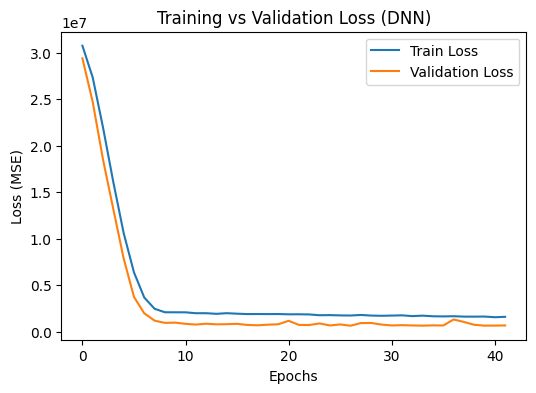

In [24]:
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training vs Validation Loss (DNN)")
plt.show()

The training and validation loss curves show:
- Rapid decrease in loss during early epochs
- Stabilization after a few iterations
- No significant divergence between training and validation loss
This indicates that overfitting is well controlled thanks to dropout and early stopping.

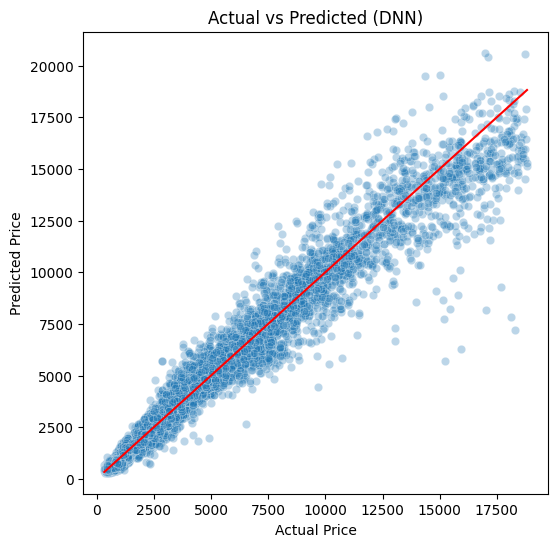

In [25]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_val, y=y_pred_dnn, alpha=0.3)
plt.plot([y_val.min(), y_val.max()],[y_val.min(), y_val.max()], color="red")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (DNN)")
plt.show()

he neural network captures the general trend of the data.
However, predictions show slightly higher dispersion compared to XGBoost.
This indicates lower predictive accuracy.

**MODEL COMPARISON**

In [26]:
comparison = pd.DataFrame({"Model": ["XGBoost", "Neural Network"],"MSE": [mse_xgb, mse_dnn],"RMSE": [rmse_xgb, rmse_dnn],"R2": [r2_xgb, r2_dnn]})
comparison

,Model,MSE,RMSE,R2
0,XGBoost,270427.03125,520.025991,0.982888
1,Neural Network,635329.25000,797.075436,0.959798


XGBoost outperforms the neural network in terms of accuracy.
This confirms that tree-based models are highly effective for tabular datasets.
However, neural networks still provide competitive results.

**CONCLUSIONS**

The analysis shows that diamond prices are mainly driven by size-related variables, in particular carat and the physical dimensions (x, y, z).
Among these, the variable y emerges as the most important predictor, followed by carat, confirming that larger diamonds tend to have higher prices.
Quality-related features such as clarity and color have a secondary but still relevant role, while cut, depth, and table provide limited additional information.
The relationships between variables and price are clearly non-linear, making advanced models more suitable than linear approaches.
Overall, XGBoost achieves the best performance, demonstrating strong predictive power and the ability to capture complex patterns in structured data.